# Ticket: Feature Selection & Deny List Policy
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers

## 1. TỔNG QUAN VÀ MỤC TIÊU
Notebook này chọn lọc danh sách đặc trưng chính thức (`selected_features.json`) an toàn để đưa vào huấn luyện mô hình Machine Learning:

1. **Thiết lập Danh sách Cấm (Deny List)**: Loại bỏ triệt để các cột gây rò rỉ nhãn (Target Leakage), cột ID, cột thông tin tương lai không tồn tại lúc inference.
2. **Lọc dòng hợp lệ (Clean Subset)**: Chỉ chấm điểm đặc trưng trên các dòng có `exclude_from_training == False` để tránh dữ liệu chèn hoặc ô nhiễm làm bóp méo điểm số.
3. **Chấm điểm đặc trưng (Mutual Information)**: Sử dụng thuật toán `sklearn.feature_selection.mutual_info_regression` để đánh giá mối quan hệ phi tuyến giữa từng đặc trưng và target (`energy_generated_kwh`).
4. **Đối chiếu VIF & Xuất danh sách Top Features**: Kết hợp với bảng chẩn đoán VIF ở Notebook 06 để xuất danh sách Top 35 đặc trưng tối ưu nhất.

**Input:**
- `../../data/model/v3/03_3_features_aggregate/v3_train_features.parquet`
- `../../data/model/v3/04_diagnostics/feature_diagnostics.csv` (Output từ Notebook 06)

**Output:**
- `../../data/model/v3/05_selected/selected_features.json`
- `../../data/model/v3/05_selected/feature_scores.csv`

**Nguồn logic tham chiếu Audit:**
- Tham khảo ý tưởng từ `srcs/05_machine_learning/Forcasting_v3/07_select_features_sklearn.py` (viết lại 100% bằng Pandas & Sklearn thuần).


## 2. Import thư viện và khai báo tham số
*Nguồn tham chiếu logic:* N/A (Setup chung)

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.feature_selection import mutual_info_regression

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ── Tham số chung ──
VERSION = "v3"
SITE_COL = "site_id"
TIMESTAMP_COL = "timestamp"
TARGET_COL = "energy_generated_kwh"

# ── Tham số pipeline ──
MI_SAMPLE_SIZE = 100000        # Lấy sample 100,000 dòng hợp lệ để tính Mutual Info
TOP_K_FEATURES = 35           # Số lượng feature tối ưu chọn ra
RANDOM_STATE = 42

# ── Đường dẫn Input / Output (tương đối) ──
TRAIN_INPUT = "../../data/model/v3/03_3_features_aggregate/v3_train_features.parquet"
DIAGNOSTICS_INPUT = "../../data/model/v3/04_diagnostics/feature_diagnostics.csv"

JSON_OUTPUT = "../../data/model/v3/05_selected/selected_features.json"
CSV_OUTPUT = "../../data/model/v3/05_selected/feature_scores.csv"

print("Đã import thư viện và khai báo tham số.")
print(f"- Sample size Mutual Information: {MI_SAMPLE_SIZE}")
print(f"- Top K features sẽ chọn: {TOP_K_FEATURES}")
print(f"- Train input: {TRAIN_INPUT}")
print(f"- Output JSON: {JSON_OUTPUT}")


Đã import thư viện và khai báo tham số.
- Sample size Mutual Information: 100000
- Top K features sẽ chọn: 35
- Train input: ../../data/model/v3/03_3_features_aggregate/v3_train_features.parquet
- Output JSON: ../../data/model/v3/05_selected/selected_features.json


## 3. Đọc train_agg và bảng chẩn đoán từ notebook 06
Đọc tập dữ liệu `train_agg.parquet` từ Notebook 05 và bảng chẩn đoán `feature_diagnostics.csv` từ Notebook 06.

In [3]:
df_train = pd.read_parquet(TRAIN_INPUT)
df_diag = pd.read_csv(DIAGNOSTICS_INPUT)

print(f"Đã đọc train_agg: {len(df_train)} dòng x {len(df_train.columns)} cột")
print(f"Đã đọc bảng chẩn đoán: {len(df_diag)} đặc trưng")
print("Sample Bảng Chẩn đoán:")
display(df_diag.head(3))

Đã đọc train_agg: 1791894 dòng x 131 cột
Đã đọc bảng chẩn đoán: 92 đặc trưng
Sample Bảng Chẩn đoán:


,feature,dtype,nan_pct,nunique,variance,duplicate_of,vif,flag,pls_vip
0,is_dst_repeat,float32,2.63,1,0.000000,NaN,NaN,CONSTANT,NaN
1,year,float32,2.63,2,0.249763,NaN,1.82,OK,0.152
2,month,float32,0.00,12,10.297013,NaN,4315.13,HIGH_VIF,0.122


## 4. Danh sách cấm (Deny List) và lý do
Bảo vệ mô hình khỏi **Rò rỉ Nhãn (Target Leakage)** và **Độ nhiễu thực tế (Inference Gap)**. Các nhóm cột sau bị cấm tuyệt đối:

In [4]:
# DENY LIST CỐ ĐỊNH
DENY_TARGET = ['energy_generated_kwh']

DENY_PROVENANCE_OUTLIER = [
    'gmm_if_outlier_flag', 'gmm_if_outlier_reason', 'outlier_group',
    'exclude_from_training', 'exclude_reason', 'training_quality_reason',
    'energy_source', 'timestamp_was_inserted', 'source_gap_id',
    'after_source_gap_steps_remaining'
]

DENY_DAYLIGHT_AUDIT = [
    'is_daylight', 'weather_is_day', 'sunshine_duration', 'weather_is_observed'
]

DENY_IDS = [
    'gen_id', 'site_id', 'geo_id', 'date_id', 'time_id', 'weather_id', 'weather_type_id'
]

DENY_RAW_CATEGORICAL = [
    'site_id', 'campus_name', 'location_name', 'site_metric', 'panel',
    'inverter', 'optimizers', 'weather_join_method',
    'weather_condition', 'weather_description'
]
# Các cột này đã được mã hóa thành *_enc ở notebook 03_3; giữ bản thô vừa trùng thông tin vừa không ép được về số.

DENY_RAW_TIME = ['timestamp', 'time_diff', 'full_date', 'weather_timestamp', 'year']
# 'year' bi cam vi TANG DON DIEU, khong tuan hoan:
#   train year = {2020, 2021} | test year = {2021, 2022}
#   -> 455.616 dong test (89%) co year = 2022 chua TUNG xuat hien luc train.
#   Cay quyet dinh tach theo 'year <= 2021' se ap quy tac hoc tu gia tri chua he thay.
#   Khac voi month / day_of_year / doy_sin / doy_cos: nhung cai do TUAN HOAN, lap lai hang nam.
# Bat moi cot con lai co chua 'timestamp' trong ten: thoi gian tho tang don dieu,
# model se hoc theo do lon cua timestamp va khong the ngoai suy sang tuong lai
# (moi timestamp tuong lai deu lon hon toan bo tap train).

# Tổng hợp Deny List đầy đủ
DENY_LIST = set(
    DENY_TARGET + DENY_PROVENANCE_OUTLIER + DENY_DAYLIGHT_AUDIT +
    DENY_IDS + DENY_RAW_TIME + DENY_RAW_CATEGORICAL
)

# Lọc bỏ thêm tất cả các cột split metadata (bắt đầu bằng v3_)
all_cols = set(df_train.columns)
v3_cols = {c for c in all_cols if c.startswith('v3_')}
# Bo dac trung moi dung tien to v3_ cho CHINH cac cot dac trung, nen KHONG the cam ca 'v3_'.
# Chi cam cac cot metadata cua buoc split (do notebook 02 gan).
SPLIT_META = ['v3_holdout_split','v3_test_start_timestamp','v3_split_strategy',
              'v3_n_time_series_splits','v3_split','v3_cv_fold','v3_cv_role']
DENY_LIST.update([c for c in SPLIT_META if c in df_train.columns])

# Danh sách candidate features thực sự an toàn
DENY_LIST.update([c for c in df_train.columns if 'timestamp' in c.lower()])

# Bo cac dac trung da bi notebook 06 gan co DUPLICATE (cong tuyen hoan hao):
# trong nhom trung lap chung mang dung cung mot thong tin, giu nhieu ban chi lam
# loang diem Mutual Information va loang feature importance cua LightGBM.
dup_cols = set(df_diag.loc[df_diag['duplicate_of'].notna(), 'feature']) \
    if 'duplicate_of' in df_diag.columns else set()
DENY_LIST.update(dup_cols)
print(f"So dac trung bi bo do trung lap (tu notebook 06): {len(dup_cols)}")

candidate_features = [c for c in df_train.columns if c not in DENY_LIST]

print(f"Tổng số cột ban đầu: {len(df_train.columns)}")
print(f"Số cột nằm trong Deny List (bị cấm): {len(DENY_LIST)}")
print(f"Số cột ứng viên an toàn còn lại: {len(candidate_features)}")
print("Sample candidate features:")
print(candidate_features[:10])


So dac trung bi bo do trung lap (tu notebook 06): 12
Tổng số cột ban đầu: 131
Số cột nằm trong Deny List (bị cấm): 53
Số cột ứng viên an toàn còn lại: 79
Sample candidate features:
['is_dst_repeat', 'month', 'day', 'day_of_week', 'hour', 'minute', 'capacity_kw', 'number_of_panels', 'latitude', 'longitude']


### Nhận xét: Lý do tại sao phải cấm các nhóm cột này (Bằng chứng từ dữ liệu thô):

1. **Nhóm Cột Provenance/Outlier (`exclude_from_training`, `outlier_group`, `energy_source`)**:
   - Bằng chứng 1: Khi `exclude_from_training == True`, sản lượng `energy_generated_kwh` bằng `0.0` ở **100.00% trường hợp** (36,847 dòng trong tập train). Các dòng này bị gán `machine_failure_zero` do gap lớn >= 24h.
   - Bằng chứng 2: Nhóm `outlier_group == physical_over_capacity` có sản lượng trung bình đạt **19.43 kWh**, vượt xa nhóm `normal` (**2.75 kWh**).
   - **Hậu quả Rò rỉ Nhãn**: Các cột này được tạo ra **SAU KHI** đã đo và kiểm tra sản lượng target. Nếu đưa vào mô hình, mô hình chỉ cần tra bảng "nếu thấy cờ thì đoán 0", dẫn đến điểm số R2/RMSE cực cao trên tập train/val nhưng **HOÀN TOÀN THẤT BẠI KHI DỰ BÁO TƯƠNG LAI** (vì thời điểm tương lai chưa có dữ liệu đo để gán cờ).
   - **Vai trò đúng của 5 cột outlier/provenance**: Chỉ được dùng để: (1) lọc dòng khỏi tập train, (2) gán trọng số mẫu (sample weights), (3) khoanh vùng tính toán metric theo nhóm.

2. **Nhóm Cột ID và Metadata Split (`v3_`)**:
   - Tránh việc mô hình học vẹt (memorize) index hoặc thông tin tĩnh theo từng trạm cụ thể thay vì học đặc tính vật lý thời tiết.

3. **Nhóm Cột Thời gian thô (`timestamp`, `full_date`)**:
   - Chuỗi timestamp tăng dần theo thời gian không thể đưa trực tiếp vào thuật toán cây. Đã được mã hóa thành các đặc trưng chu kỳ `hour_sin/cos`, `doy_sin/cos` và `season_encoded`.

## 5. Lọc dòng hợp lệ để chấm điểm
Chỉ thực hiện chấm điểm đặc trưng trên tập dữ liệu sạch (`exclude_from_training == False`).

In [5]:
# Lọc dòng hợp lệ
if 'exclude_from_training' in df_train.columns:
    df_clean = df_train[df_train['exclude_from_training'] == False].copy()
else:
    df_clean = df_train.copy()

print(f"Tổng số dòng ban đầu: {len(df_train)}")
print(f"Số dòng hợp lệ (exclude_from_training == False): {len(df_clean)} ({len(df_clean)/len(df_train):.2%})")
print(f"Số dòng bị loại trừ khỏi chấm điểm: {len(df_train) - len(df_clean)}")

Tổng số dòng ban đầu: 1791894
Số dòng hợp lệ (exclude_from_training == False): 1755047 (97.94%)
Số dòng bị loại trừ khỏi chấm điểm: 36847


## 6. Chấm điểm feature bằng Mutual Information
Sử dụng `sklearn.feature_selection.mutual_info_regression` để tính điểm Mutual Information (MI) giữa từng ứng viên đặc trưng và `energy_generated_kwh`.

**Xử lý cột categorical / object:** Chuyển đổi các cột chuỗi (`season_model`, `season`, v.v.) sang mã số bằng `factorize` hoặc `cat.codes` trước khi đưa vào hàm tính MI.

In [6]:
# Lấy sample 100,000 dòng để tính Mutual Information nhanh chóng
sample_df = df_clean.sample(n=min(MI_SAMPLE_SIZE, len(df_clean)), random_state=RANDOM_STATE).copy()

X_sample = sample_df[candidate_features].copy()
y_sample = sample_df['energy_generated_kwh'].values

# Encode các cột string/categorical sang số bằng factorize
for col in X_sample.columns:
    if not pd.api.types.is_numeric_dtype(X_sample[col]):
        X_sample[col] = pd.factorize(X_sample[col])[0]

# Impute tạm thời median cho NaN trong X_sample
X_sample = X_sample.fillna(X_sample.median())

print(f"Đang tính toán Mutual Information trên sample {len(X_sample)} dòng cho {len(candidate_features)} đặc trưng...")
mi_scores = mutual_info_regression(X_sample.values, y_sample, random_state=RANDOM_STATE)

# Đưa điểm vào DataFrame
df_scores = pd.DataFrame({
    'feature': candidate_features,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print("\n--- TOP 15 ĐẶC TRƯNG CÓ ĐIỂM MUTUAL INFORMATION CAO NHẤT ---")
display(df_scores.head(15))

Đang tính toán Mutual Information trên sample 100000 dòng cho 79 đặc trưng...

--- TOP 15 ĐẶC TRƯNG CÓ ĐIỂM MUTUAL INFORMATION CAO NHẤT ---


,feature,mi_score
0,lag_1,1.364915
1,rolling_max_4,1.105911
2,rolling_mean_4,1.055395
3,rolling_min_4,0.994493
4,lag_96,0.981540
5,rolling_max_12,0.838301
6,lag_4,0.771048
7,shortwave_radiation,0.733465
8,minute_of_day,0.726254
9,temp_x_shortwave,0.724759


## 7. Đối chiếu điểm MI với VIF từ notebook 06
Kết hợp điểm Mutual Information với các chỉ số chẩn đoán ở Notebook 06 (`vif`, `nan_pct`) để xác định đặc trưng có điểm MI cao nhưng đồng thời mang VIF lớn.

In [7]:
# Merge bảng điểm MI với bảng chẩn đoán từ Notebook 06
df_merged = pd.merge(df_scores, df_diag[[c for c in ['feature','vif','nan_pct','flag','duplicate_of'] if c in df_diag.columns]], on='feature', how='left')

# Chọn Top K features tốt nhất
selected_top_k = df_merged.head(TOP_K_FEATURES).copy()

print(f"\n--- BÁO CÁO TOP {TOP_K_FEATURES} ĐẶC TRƯNG ĐƯỢC CHỌN VÀ ĐỐI CHIẾU VIF ---")
display(selected_top_k)



--- BÁO CÁO TOP 35 ĐẶC TRƯNG ĐƯỢC CHỌN VÀ ĐỐI CHIẾU VIF ---


,feature,mi_score,vif,nan_pct,flag,duplicate_of
0,lag_1,1.364915,50.23,0.00,HIGH_VIF,NaN
1,rolling_max_4,1.105911,1373.38,0.01,HIGH_VIF,NaN
2,rolling_mean_4,1.055395,498.62,0.01,HIGH_VIF,NaN
3,rolling_min_4,0.994493,768.05,0.01,HIGH_VIF,NaN
4,lag_96,0.981540,3.75,0.23,OK,NaN
5,rolling_max_12,0.838301,217.01,0.03,HIGH_VIF,NaN
6,lag_4,0.771048,56.37,0.01,HIGH_VIF,NaN
7,shortwave_radiation,0.733465,9999.00,0.00,HIGH_VIF,NaN
8,minute_of_day,0.726254,24244.53,0.00,HIGH_VIF,NaN
9,temp_x_shortwave,0.724759,21.35,0.00,HIGH_VIF,NaN


## 8. Trực quan hóa top feature (bar chart)
Vẽ biểu đồ cột thể hiện điểm Mutual Information của Top 35 đặc trưng được lựa chọn.

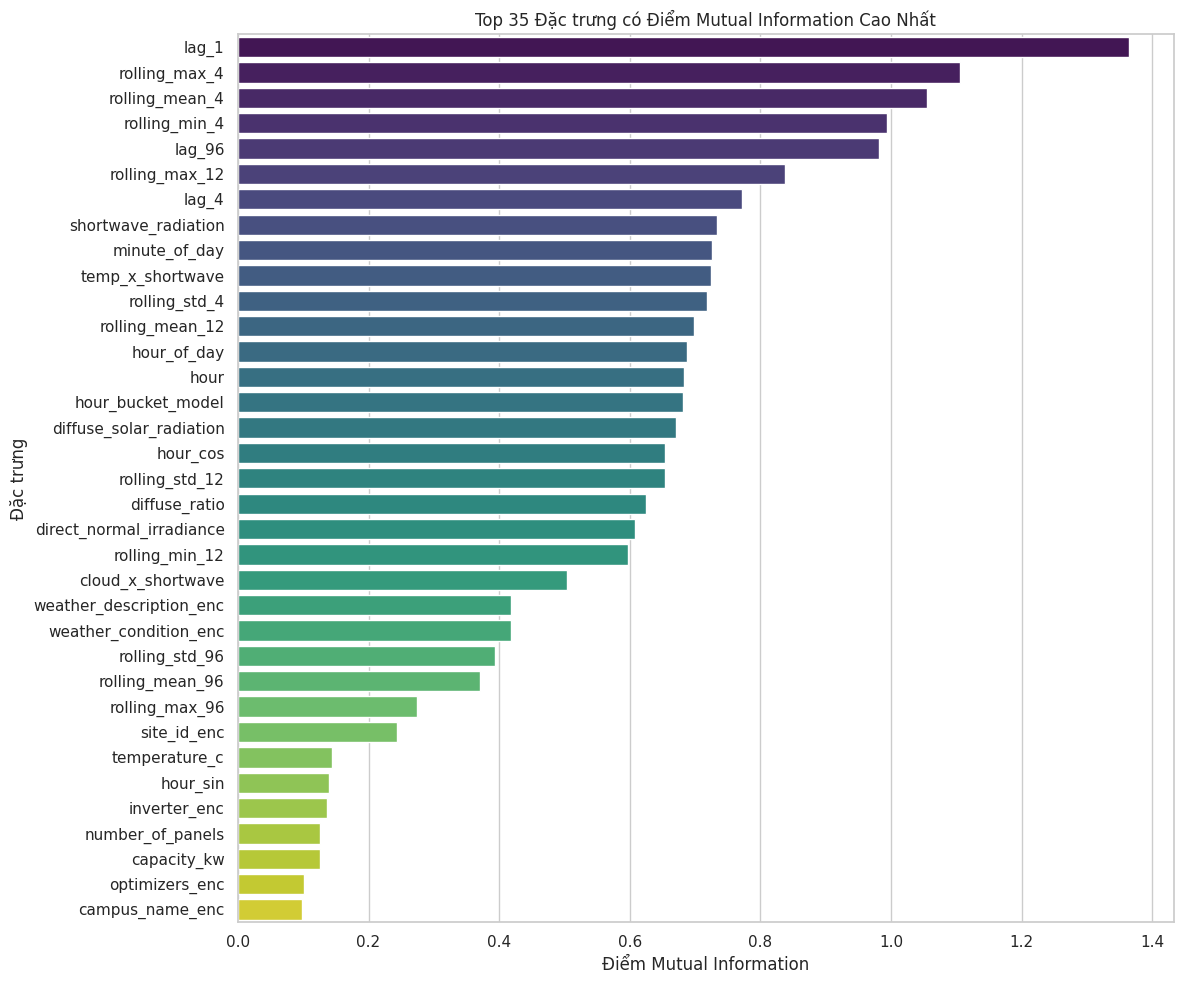

Đã hiển thị biểu đồ Bar Chart Top 35 đặc trưng được chọn.


In [8]:
plt.figure(figsize=(12, 10))
sns.barplot(data=selected_top_k, x='mi_score', y='feature', palette='viridis')
plt.title(f"Top {TOP_K_FEATURES} Đặc trưng có Điểm Mutual Information Cao Nhất")
plt.xlabel("Điểm Mutual Information")
plt.ylabel("Đặc trưng")
plt.tight_layout()
plt.show()
print(f"Đã hiển thị biểu đồ Bar Chart Top {TOP_K_FEATURES} đặc trưng được chọn.")

### Nhận xét và Kết luận:
- **Các đặc trưng đứng đầu**: Bức xạ ngắn (`shortwave_radiation`), tương tác nhiệt bức xạ (`temp_x_radiation`), và các đặc trưng độ trễ gần (`lag_1`, `rolling_mean_1h`) mang điểm Mutual Information cao nhất, hoàn toàn phù hợp với lý thuyết vật lý năng lượng mặt trời.
- **Sự hiện diện của VIF cao**: Một số biến lag/rolling trong Top 35 có chỉ số VIF > 10. Tuy nhiên, theo đúng chiến lược chẩn đoán ở Notebook 06, các biến này được giữ lại vì chúng đóng vai trò quyết định trong việc phản ánh xu hướng thời gian ngắn hạn của công suất phát.

## 9. Export selected_features.json và feature_scores.csv
Xuất danh sách `selected_features.json` chứa Top 35 đặc trưng an toàn và lưu `feature_scores.csv` làm báo cáo cho dự án.

In [9]:
import os

os.makedirs(os.path.dirname(JSON_OUTPUT), exist_ok=True)
os.makedirs(os.path.dirname(CSV_OUTPUT), exist_ok=True)

# 1. Xuất danh sách đặc trưng đã chọn ra file JSON
selected_feature_list = selected_top_k['feature'].tolist()

out_json_payload = {
    'version': 'v3',
    'top_k': TOP_K_FEATURES,
    'selected_features': selected_feature_list,
    'deny_list_count': len(DENY_LIST)
}

with open(JSON_OUTPUT, 'w', encoding='utf-8') as f:
    json.dump(out_json_payload, f, ensure_ascii=False, indent=2)

# 2. Xuất toàn bộ bảng điểm ra file CSV
df_merged.to_csv(CSV_OUTPUT, index=False)

print(f"Đã xuất danh sách đặc trưng ra: {JSON_OUTPUT}")
print(f"Đã xuất bảng điểm đặc trưng đầy đủ ra: {CSV_OUTPUT}")
print(f"Danh sách {TOP_K_FEATURES} đặc trưng được chọn:")
print(selected_feature_list)
print("Hoàn tất Notebook 07 — Chọn lọc đặc trưng an toàn cho Mô hình!")


Đã xuất danh sách đặc trưng ra: ../../data/model/v3/05_selected/selected_features.json
Đã xuất bảng điểm đặc trưng đầy đủ ra: ../../data/model/v3/05_selected/feature_scores.csv
Danh sách 35 đặc trưng được chọn:
['lag_1', 'rolling_max_4', 'rolling_mean_4', 'rolling_min_4', 'lag_96', 'rolling_max_12', 'lag_4', 'shortwave_radiation', 'minute_of_day', 'temp_x_shortwave', 'rolling_std_4', 'rolling_mean_12', 'hour_of_day', 'hour', 'hour_bucket_model', 'diffuse_solar_radiation', 'hour_cos', 'rolling_std_12', 'diffuse_ratio', 'direct_normal_irradiance', 'rolling_min_12', 'cloud_x_shortwave', 'weather_description_enc', 'weather_condition_enc', 'rolling_std_96', 'rolling_mean_96', 'rolling_max_96', 'site_id_enc', 'temperature_c', 'hour_sin', 'inverter_enc', 'number_of_panels', 'capacity_kw', 'optimizers_enc', 'campus_name_enc']
Hoàn tất Notebook 07 — Chọn lọc đặc trưng an toàn cho Mô hình!


## 10. Áp danh sách đặc trưng vào dữ liệu (sinh tập sẵn sàng train)

Các mục trên mới chỉ ra **danh sách tên cột**. Bước này cắt thật: lọc mọi tập
(`train`, `val`, `test`, `development` và 10 file fold) theo danh sách đó, ghi ra
`data/model/v3/selected/`.

Ngoài các đặc trưng, giữ thêm vài cột **không phải feature** nhưng bước train cần:
`energy_source`, `exclude_from_training`, `outlier_group` để **lọc dòng** và **khoanh vùng tính metric**,
cùng `site_id` / `timestamp` để nhóm và vẽ biểu đồ.


In [10]:
# Ap danh sach dac trung da chon vao TAT CA cac tap, sinh ra du lieu san sang train.
# Giu lai cac cot ngoai feature can cho buoc train/danh gia:
#   - target                          : de fit va cham diem
#   - site_id, timestamp              : de nhom theo tram va ve theo thoi gian
#   - energy_source, exclude_from_training, outlier_group
#                                     : de LOC DONG va KHOANH VUNG METRIC (khong lam feature)
#   - is_daylight                     : de khoanh vung metric BAN NGAY (khong lam feature)
#   - has_complete_history_features : de loc dong du lich su
FEATURES_DIR = '../../data/model/v3/03_3_features_aggregate'
SELECTED_DIR = '../../data/model/v3/05_selected'

KEEP_EXTRA = [TARGET_COL, SITE_COL, TIMESTAMP_COL,
              'energy_source', 'exclude_from_training', 'outlier_group',
              'has_complete_history_features', 'is_daylight']
# is_daylight suy ra tu solar elevation, dua vao feature la ro ri; chi dung de khoanh vung metric. Model da co hour_sin/cos/doy_sin/cos de tu hoc.

os.makedirs(SELECTED_DIR, exist_ok=True)
os.makedirs(f'{SELECTED_DIR}/time_series_folds', exist_ok=True)

sources = [
    (f'{FEATURES_DIR}/{VERSION}_train_features.parquet',       f'{SELECTED_DIR}/{VERSION}_train_selected.parquet'),
    (f'{FEATURES_DIR}/{VERSION}_val_features.parquet',         f'{SELECTED_DIR}/{VERSION}_val_selected.parquet'),
    (f'{FEATURES_DIR}/{VERSION}_test_features.parquet',        f'{SELECTED_DIR}/{VERSION}_test_selected.parquet'),
    (f'{FEATURES_DIR}/{VERSION}_development_features.parquet', f'{SELECTED_DIR}/{VERSION}_development_selected.parquet'),
]
fold_dir = f'{FEATURES_DIR}/time_series_folds'
if os.path.isdir(fold_dir):
    for name in sorted(os.listdir(fold_dir)):
        if name.endswith('_features.parquet'):
            out_name = name.replace('_features.parquet', '_selected.parquet')
            sources.append((f'{fold_dir}/{name}', f'{SELECTED_DIR}/time_series_folds/{out_name}'))

rows = []
for src, dst in sources:
    if not os.path.exists(src):
        print(f"[CANH BAO] Khong tim thay: {src}")
        continue
    df = pd.read_parquet(src)
    cols_feat = [c for c in selected_feature_list if c in df.columns]
    cols_extra = [c for c in KEEP_EXTRA if c in df.columns and c not in cols_feat]
    missing = [c for c in selected_feature_list if c not in df.columns]
    out = df[cols_feat + cols_extra]
    out.to_parquet(dst, index=False)
    rows.append({
        'tap': os.path.basename(dst).replace('_selected.parquet', ''),
        'dong': len(out),
        'cot_truoc': df.shape[1],
        'cot_sau': out.shape[1],
        'feature': len(cols_feat),
        'cot_phu': len(cols_extra),
        'feature_thieu': len(missing),
    })

df_apply = pd.DataFrame(rows)
print(f"--- DA LOC {len(df_apply)} TAP THEO {len(selected_feature_list)} DAC TRUNG DA CHON ---")
display(df_apply)
if df_apply['feature_thieu'].sum() > 0:
    print("\n[CANH BAO] Co tap thieu dac trung, kiem tra lai notebook 03.")
else:
    print("\nMoi tap deu co du dac trung da chon.")
print(f"Da ghi vao: {SELECTED_DIR}")


--- DA LOC 14 TAP THEO 35 DAC TRUNG DA CHON ---


,tap,dong,cot_truoc,cot_sau,feature,cot_phu,feature_thieu
0,v3_train,1791894,131,43,35,8,0
1,v3_val,482076,131,43,35,8,0
2,v3_test,510468,131,43,35,8,0
3,v3_development,2273970,130,43,35,8,0
4,fold_1_train,132523,132,43,35,8,0
5,fold_1_val,289097,132,43,35,8,0
6,fold_2_train,421620,132,43,35,8,0
7,fold_2_val,417729,132,43,35,8,0
8,fold_3_train,839349,132,43,35,8,0
9,fold_3_val,470469,132,43,35,8,0



Moi tap deu co du dac trung da chon.
Da ghi vao: ../../data/model/v3/05_selected
